# Opsi 2: Temporal Graph sebagai "Super-Gate" (Risk-Off Override)

**Konsep Managemen Risiko Ekstrim:**
Pendekatan ini bertujuan menghindari krisis sistemik (Black Swan) dengan mendeteksi kerapuhan struktur pasar melalui korelasi tinggi antar aset.

1.  **AI Gatekeeper**: Random Forest standar (fitur: `Vol_20`, `Mom_20`, `Mom_50`) memprediksi tren makro harian.
2.  **Temporal Graph Density**: Setiap hari dihitung kepadatan graf (Graph Density) dari korelasi 30 hari terakhir.
3.  **The "Hard Veto" Rule**:
    -   Jika **Graph Density > 0.8** (Pasar berkorelasi sangat ekstrim/berbahaya) $\rightarrow$ **FORCE RISK-OFF** (100% Cash), abaikan sinyal AI Bullish.
    -   Jika **Graph Density <= 0.8** $\rightarrow$ Ikuti sinyal AI (Bull: Markowitz, Bear: Cash).
4.  **Keunggulan**: Memberikan perlindungan ganda. AI menangani tren, Grafik menangani risiko sistemik korelasi mendadak.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import os
from tqdm import tqdm

# Config
plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")

## 1. Data Loading

In [2]:
file_path = 'dataset_2023_2025.xlsx'
if os.path.exists(file_path):
    print(f"Loading data from {file_path}...")
    data = pd.read_excel(file_path, index_col=0, parse_dates=True)
else:
    print("File data tidak ditemukan!")

print(f"Data Shape: {data.shape}")

Loading data from dataset_2023_2025.xlsx...
Data Shape: (990, 24)


## 2. Daily Graph Density Extraction
Kita hitung density harian untuk mendeteksi korelasi sistemik.

Calculating Daily Graph Density...


100%|██████████| 947/947 [00:00<00:00, 2684.31it/s]


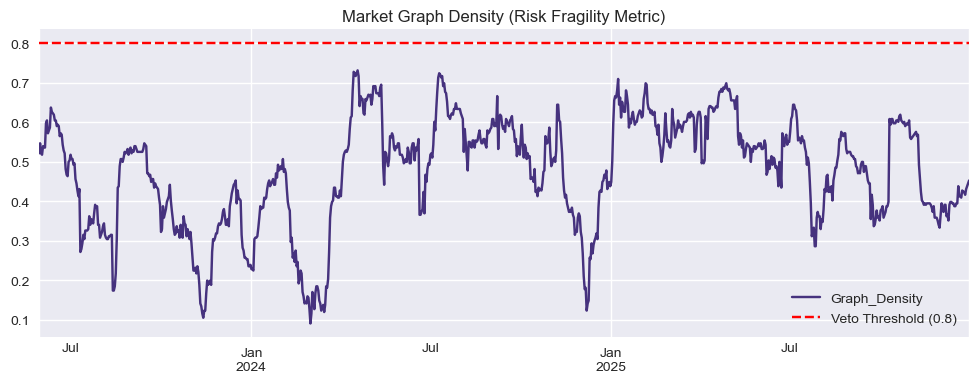

In [3]:
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

def extract_daily_density(returns_df, window=30, threshold=0.5):
    densities = []
    dates = []
    print("Calculating Daily Graph Density...")
    for i in tqdm(range(window, len(returns_df))):
        window_data = returns_df.iloc[i-window:i]
        current_date = returns_df.index[i]
        
        # Correlation matrix
        corr_mat = window_data.corr().abs()
        
        # Build Graph
        G = nx.Graph()
        assets = window_data.columns
        G.add_nodes_from(assets)
        
        # Edge additions where correlation > threshold
        corr_values = corr_mat.values
        rows, cols = np.where(np.triu(corr_values, k=1) > threshold)
        edges = [(assets[r], assets[c]) for r, c in zip(rows, cols)]
        G.add_edges_from(edges)
        
        densities.append(nx.density(G))
        dates.append(current_date)
        
    return pd.Series(densities, index=dates, name='Graph_Density')

daily_density = extract_daily_density(returns, window=30, threshold=0.5)

# Visualisasi Density
plt.figure(figsize=(12, 4))
daily_density.plot(title='Market Graph Density (Risk Fragility Metric)')
plt.axhline(y=0.8, color='r', linestyle='--', label='Veto Threshold (0.8)')
plt.legend()
plt.show()

## 3. Train Baseline AI
Hanya menggunakan fitur pasar standar.

In [4]:
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()
features['Target'] = (market_return.shift(-1) > 0).astype(int)
features = features.dropna()

train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask, ['Vol_20', 'Mom_20', 'Mom_50']], features.loc[train_mask, 'Target']
X_test, y_test = features.loc[test_mask, ['Vol_20', 'Mom_20', 'Mom_50']], features.loc[test_mask, 'Target']

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

test_probs = pd.Series(rf_model.predict_proba(X_test)[:, 1], index=X_test.index)

## 4. Backtest with Super-Gate Logic
Di sini kita menerapkan aturan **OVERRIDE** jika Density > 0.8.

In [5]:
def optimize_markowitz(selected_assets_returns):
    mu = selected_assets_returns.mean() * 252
    sigma = selected_assets_returns.cov() * 252
    num_assets = len(mu)
    
    def neg_sharpe_ratio(weights):
        port_return = np.sum(weights * mu)
        port_volatility = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -port_return / port_volatility if port_volatility > 0 else 0
    
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    initial_guess = num_assets * [1. / num_assets]
    
    result = minimize(neg_sharpe_ratio, initial_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_assets_returns.columns, result.x))

initial_capital = 10000.0
current_value = initial_capital
history = []
DENSITY_THRESHOLD = 0.8

test_dates = X_test.index

for i, date in enumerate(test_dates):
    # 1. Get Density for this date
    density = daily_density.loc[date] if date in daily_density.index else 0
    ai_signal = test_probs.loc[date] > 0.5
    
    regime = ""
    weights = {}
    
    # SUPER-GATE TRIGGER CHECK
    if density > DENSITY_THRESHOLD:
        # HARD VETO: Force Risk-Off
        weights = {'CASH': 1.0}
        regime = "VETO_BEAR"
    else:
        # Normal AI Gatekeeper decision
        if ai_signal:
            regime = "BULL"
            loc_idx = returns.index.get_loc(date)
            window_returns = returns.iloc[loc_idx-30:loc_idx]
            weights = optimize_markowitz(window_returns)
        else:
            regime = "BEAR"
            weights = {'CASH': 1.0}
            
    # Calculate Performance
    if i < len(test_dates) - 1:
        next_date = test_dates[i+1]
        next_day_returns = returns.loc[next_date]
        
        daily_ret = 0
        if 'CASH' not in weights:
            for asset, w in weights.items():
                daily_ret += w * next_day_returns[asset]
        
        current_value *= (1 + daily_ret)
        history.append({
            'Date': next_date, 
            'Value': current_value, 
            'Regime': regime, 
            'Density': density
        })

perf_df = pd.DataFrame(history).set_index('Date')
print("Backtest Complete.")

Backtest Complete.


## 5. Visualisasi & Analisis

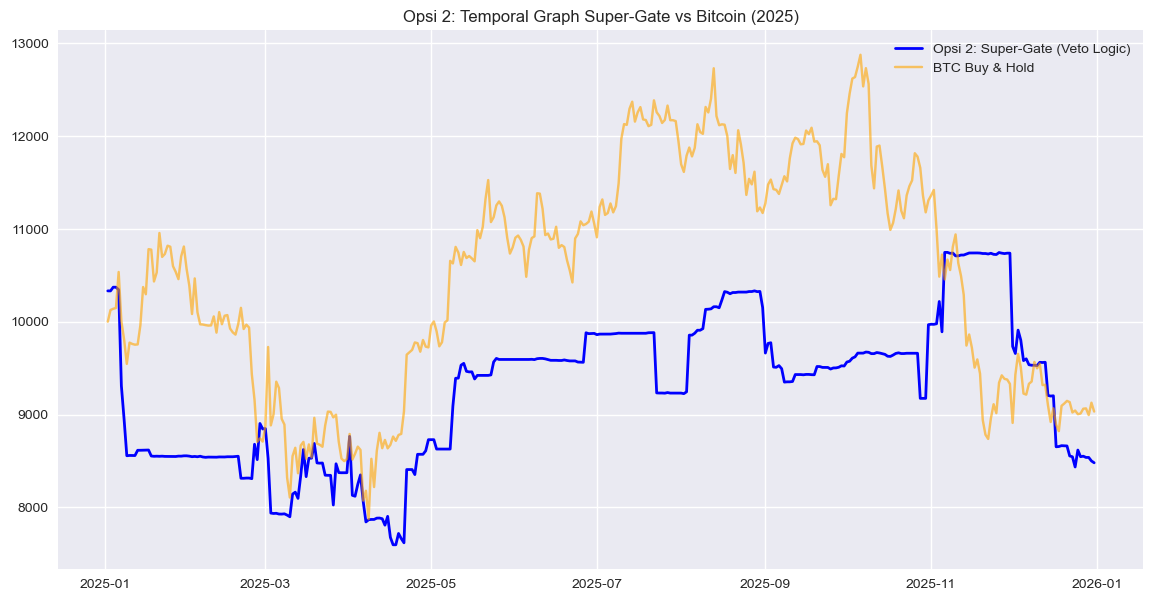

Final Value Opsi 2: $8479.92
Final Value BTC: $9032.06


In [6]:
btc_prices = data.loc[perf_df.index, 'BTC-USD']
btc_normalized = (btc_prices / btc_prices.iloc[0]) * initial_capital

plt.figure(figsize=(14, 7))
plt.plot(perf_df.index, perf_df['Value'], label='Opsi 2: Super-Gate (Veto Logic)', color='blue', linewidth=2)
plt.plot(btc_normalized.index, btc_normalized, label='BTC Buy & Hold', color='orange', alpha=0.6)

# Highlight Veto Periods
veto_periods = perf_df[perf_df['Regime'] == 'VETO_BEAR']
if not veto_periods.empty:
    plt.scatter(veto_periods.index, veto_periods['Value'], color='red', label='Super-Gate Veto (Risk-Off)', zorder=5)

plt.title('Opsi 2: Temporal Graph Super-Gate vs Bitcoin (2025)')
plt.legend()
plt.show()

print(f"Final Value Opsi 2: ${perf_df['Value'].iloc[-1]:.2f}")
print(f"Final Value BTC: ${btc_normalized.iloc[-1]:.2f}")